<a href="https://colab.research.google.com/github/mncbl/Ap1VisaoComputacional/blob/main/AP1VisaoCOmputacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics opencv-python

In [ ]:
from google.colab.patches import cv2_imshow

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4534  100  4534    0     0   6490      0 --:--:-- --:--:-- --:--:--  6495


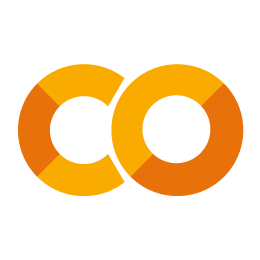

In [ ]:
!curl -o logo.png https://colab.research.google.com/img/colab_favicon_256px.png
import cv2
img = cv2.imread('logo.png', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import defaultdict

# ==========================================
# 1. CONFIGURAÇÕES INICIAIS E MODELO
# ==========================================
model = YOLO('yolov8n.pt')
VEHICLE_CLASSES = [2, 3, 5, 7] # Carro, Moto, Ônibus, Caminhão
CONFIDENCE_THRESHOLD = 0.25 # Como é de dia, podemos ser mais rigorosos na confiança

# ==========================================
# 2. CONFIGURAÇÃO DE VÍDEO
# ==========================================
video_path = '/content/drive/MyDrive/ap1visao/14726858_1080_1920_30fps.mp4' # Seu novo vídeo
cap = cv2.VideoCapture(video_path)

orig_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
orig_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
fps_efetivo = fps / 2  # Pulo de frames para otimizar processamento

# Redimensionamento dinâmico (Trava a largura para manter a proporção vertical)
novo_width = 720
novo_height = int(orig_height * (novo_width / orig_width))

# Gravador do vídeo de saída
out = cv2.VideoWriter('resultado_bruto.mp4', cv2.VideoWriter_fourcc(*'mp4v'), int(fps_efetivo), (novo_width, novo_height))

# ==========================================
# 3. ENGENHARIA DE TRÁFEGO: SENSOR DUPLO
# ==========================================
linha_y = int(novo_height * 0.70) # Linha posicionada mais embaixo (70% da tela)

# Cada sentido tem cerca de 2 faixas, então a capacidade é menor que a da via anterior
capacidade_sentido = 2400

historico_rotas = defaultdict(list)
veiculos_indo = set()  # Pista Esquerda (Subindo)
veiculos_vindo = set() # Pista Direita (Descendo)

def calcular_los_vc(razao_vc):
    if razao_vc <= 0.2: return "LOS A (Livre)", (200, 255, 100), (20, 40, 20)
    elif razao_vc <= 0.4: return "LOS B (Estavel)", (150, 255, 0), (30, 40, 20)
    elif razao_vc <= 0.7: return "LOS C (Moderado)", (0, 255, 255), (40, 40, 20)
    elif razao_vc <= 0.9: return "LOS D (Denso)", (0, 150, 255), (40, 30, 20)
    else: return "LOS E/F (Critico)", (50, 50, 255), (40, 20, 20)

# ==========================================
# 4. LOOP DE PROCESSAMENTO
# ==========================================
frame_count = 0
print("Analisando fluxo duplo da rodovia... Aguarde o processamento.")

while cap.isOpened():
    ret, frame_original = cap.read()
    if not ret: break

    frame_count += 1
    if frame_count % 2 != 0: continue # Otimização de FPS

    frame_exibicao = cv2.resize(frame_original, (novo_width, novo_height))
    overlay = frame_exibicao.copy()

    # --- DESENHO VISUAL DO SENSOR ---
    cv2.line(frame_exibicao, (0, linha_y), (novo_width, linha_y), (0, 255, 0), 2)
    cv2.putText(frame_exibicao, "SENSOR DE CRUZAMENTO", (10, linha_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Inferência da IA (Direto no frame claro do dia)
    resultados = model.track(frame_exibicao, persist=True, conf=CONFIDENCE_THRESHOLD, verbose=False)[0]

    if resultados.boxes is not None and resultados.boxes.id is not None:
        boxes = resultados.boxes.xyxy.cpu().numpy()
        clss = resultados.boxes.cls.cpu().numpy()
        ids = resultados.boxes.id.cpu().numpy()

        for box, cls, track_id in zip(boxes, clss, ids):
            if int(cls) in VEHICLE_CLASSES:
                x1, y1, x2, y2 = map(int, box)
                cx, cy = int((x1 + x2) / 2), int(y2)

                rota = historico_rotas[track_id]
                rota.append((cx, cy))
                if len(rota) > 30: rota.pop(0)

                cor_box = (150, 150, 150) # Cinza padrão

                # Lógica Vetorial e Cruzamento de Linha
                if len(rota) >= 2:
                    y_anterior = rota[-2][1]
                    y_atual = rota[-1][1]

                    # Direção do movimento
                    dy = y_atual - rota[-5][1] if len(rota) > 5 else y_atual - y_anterior

                    if dy > 2: # Descendo a tela (Pista da Direita - Vindo)
                        cor_box = (255, 150, 50) # Laranja
                        if y_anterior < linha_y and y_atual >= linha_y:
                            veiculos_vindo.add(track_id)
                    elif dy < -2: # Subindo a tela (Pista da Esquerda - Indo)
                        cor_box = (50, 200, 255) # Azul
                        if y_anterior > linha_y and y_atual <= linha_y:
                            veiculos_indo.add(track_id)

                # Renderiza box e rastro
                cv2.rectangle(frame_exibicao, (x1, y1), (x2, y2), cor_box, 2)
                for i in range(1, len(rota)):
                    cv2.line(frame_exibicao, rota[i - 1], rota[i], cor_box, 2)

    # --- MATEMÁTICA DE ENGENHARIA DE TRÁFEGO ---
    tempo_decorrido_seg = max(1, (frame_count / 2) / fps_efetivo)

    vol_h_indo = int((len(veiculos_indo) / tempo_decorrido_seg) * 3600)
    vol_h_vindo = int((len(veiculos_vindo) / tempo_decorrido_seg) * 3600)

    razao_vc_indo = vol_h_indo / capacidade_sentido
    razao_vc_vindo = vol_h_vindo / capacidade_sentido

    los_indo_txt, cor_indo, _ = calcular_los_vc(razao_vc_indo)
    los_vindo_txt, cor_vindo, _ = calcular_los_vc(razao_vc_vindo)

    # --- DASHBOARD DUPLO ---
    # Posicionado no topo para não tampar a rodovia
    cv2.rectangle(overlay, (20, 20), (700, 180), (20, 25, 30), -1)
    cv2.addWeighted(overlay, 0.85, frame_exibicao, 0.15, 0, frame_exibicao)

    cv2.putText(frame_exibicao, 'MONITORAMENTO DE FLUXO DUPLO - LOS (v/c)', (40, 50), cv2.FONT_HERSHEY_DUPLEX, 0.6, (255, 255, 255), 1)
    cv2.line(frame_exibicao, (40, 65), (680, 65), (100, 100, 100), 1)

    # Lado Esquerdo (Indo)
    cv2.putText(frame_exibicao, 'SENTIDO A (ESQUERDA)', (40, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50, 200, 255), 1)
    cv2.putText(frame_exibicao, f'Vol: {vol_h_indo} veh/h', (40, 125), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    cv2.putText(frame_exibicao, f'LOS: {los_indo_txt}', (40, 155), cv2.FONT_HERSHEY_SIMPLEX, 0.7, cor_indo, 2)

    # Lado Direito (Vindo)
    cv2.putText(frame_exibicao, 'SENTIDO B (DIREITA)', (400, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 150, 50), 1)
    cv2.putText(frame_exibicao, f'Vol: {vol_h_vindo} veh/h', (400, 125), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    cv2.putText(frame_exibicao, f'LOS: {los_vindo_txt}', (400, 155), cv2.FONT_HERSHEY_SIMPLEX, 0.7, cor_vindo, 2)

    out.write(frame_exibicao)

cap.release()
out.release()
print("Processamento concluído com sucesso!")

Analisando fluxo duplo da rodovia... Aguarde o processamento.
Processamento concluído com sucesso!


For example, here we download and display a PNG image of the Colab logo: